<a href="https://colab.research.google.com/github/anaghasurendran145-maker/mmmm/blob/main/Sentimental_analysis_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

*SENTIMENTAL ANALYSIS*

In [6]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
import nltk

In [7]:
nltk.download('stopwords')
nltk.download('vader_lexicon')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [2]:
df = pd.read_csv("/content/sentimentdataset.csv",encoding='latin1')

In [3]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! ðª ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [8]:
stop_words = set(stopwords.words('english'))

In [9]:
def clean_text(text):
    text = str(text).lower() # Convert to lowercase
    text = re.sub(r"http\S+|www\S+", "", text) # Remove URLs
    text = re.sub(r"[^a-zA-Z\s]", "", text) # Remove punctuation/emojis/special chars
    text = " ".join(word for word in text.split() if word not in stop_words) # Remove stopwords
    return text

In [11]:
df['clean_text'] = df['Text'].apply(clean_text)

**Apply Sentiment Model**

In [12]:
sia = SentimentIntensityAnalyzer()
df['score'] = df['clean_text'].apply(lambda x: sia.polarity_scores(x)['compound'])



**Classify Sentiment**

In [13]:
def classify(score):
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment_Classified'] = df['score'].apply(classify)

**VISUALIZE**



In [14]:
plt.figure(figsize=(10, 5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

/tmp/ipykernel_1737/856313771.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Sentiment_Classified', palette='viridis')


Text(0.5, 1.0, 'Sentiment Distribution (Bar Chart)')

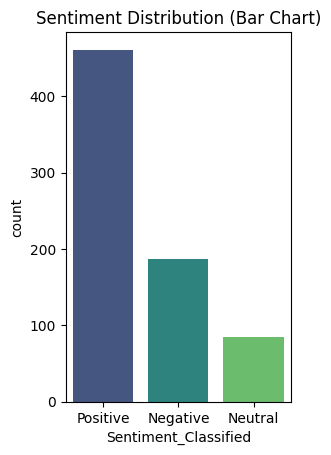

In [15]:
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='Sentiment_Classified', palette='viridis')
plt.title('Sentiment Distribution (Bar Chart)')

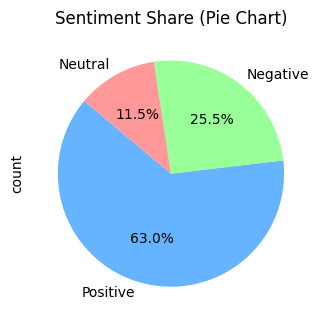

In [16]:
plt.subplot(1, 2, 2)
df['Sentiment_Classified'].value_counts().plot.pie(autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#99ff99','#ff9999'])
plt.title('Sentiment Share (Pie Chart)')
plt.tight_layout()
plt.show()

**Word Cloud**

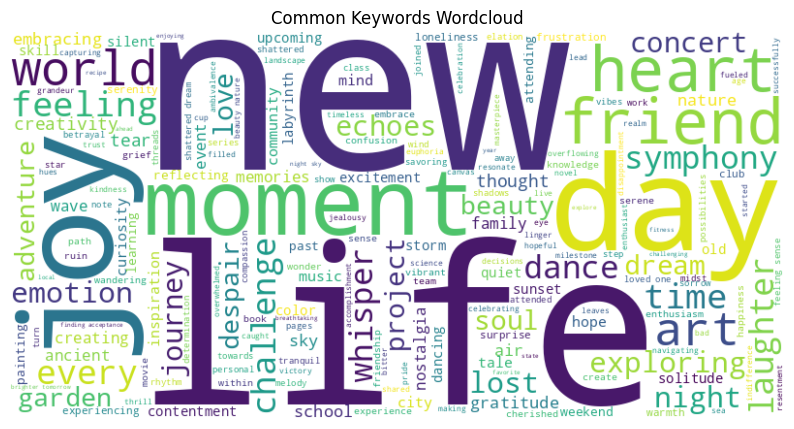

In [17]:
plt.figure(figsize=(10, 6))
wc = WordCloud(width=800, height=400, background_color='white').generate(" ".join(df['clean_text']))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title('Common Keywords Wordcloud')
plt.show()

**INSIGHTS**

1.The Sentiment that is dominating here is "Positive," "Happy," "Joy," and "Excitement".This suggests the overall tone of the dataset is optimistic.

2.When analysing the regional engagement we can see that,The USA and UK are the clear leaders in total engagement, likely due to a combination of user base size and post frequency.

3.Also analysing like by trends,nstagram holds the largest share of likes by a significant margin. This suggests that visual-first content is driving the most engagement in this dataset.